# Precios de Acciones: Entrenando un Agente de RL

## 1. Instalación e importación de librerías
**CAMBIO 1.** Usamos "yfinance" (equivalente moderno de "yahoo_finance", ya que este fue descontinuado en 2017)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
## ORIGINAL: from yahoo_finance import Share
## CAMBIO: 
import yfinance as yf
import warnings
import os
import random
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('Librerías importadas')

Librerías importadas


## 2. Obtención de datos históricos de precios

In [3]:
#    CODIGO ORIGINAL: 
# def get_prices(share_symbol, start_date, end_date, cache_filename=None):
#    try: 
#        stock_prices = np.load(cache_filename)
#    except IOError:
#        share = Share(share_symbol)
#        stock_hist = share.get_historical(start_date, end_date)
#        stock_prices = [stock_price['Open'] for stock_price in stock_hist]
#        np.save(cache_filename, stock_prices)
#    return stock_prices

In [4]:
def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except (IOError, FileNotFoundError):
        ticker = yf.Ticker(share_symbol)    #Cambio
        stock_hist = ticker.history(start=start_date, end=end_date)    #Cambio
        stock_prices = stock_hist['Open'].values.astype(float)    #Cambio
        np.save(cache_filename, stock_prices)
    return stock_prices

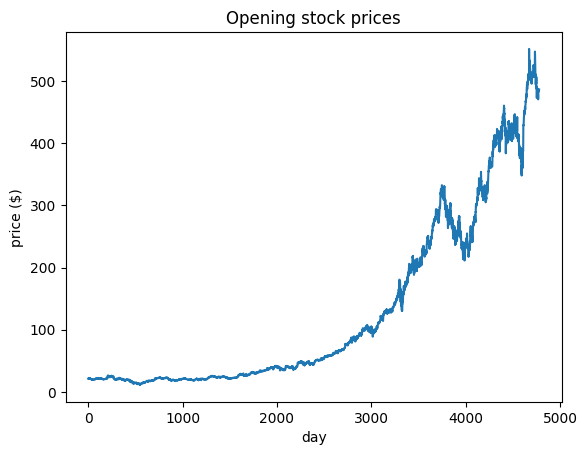

In [5]:
def plot_prices(prices):
    plt.title('Opening stock prices')
    plt.xlabel('day')
    plt.ylabel('price ($)')
    plt.plot(prices)
    plt.savefig('prices.png')

if __name__ == '__main__':
    prices = get_prices('MSFT', '2007-01-01', '2026-01-01', 'historical_stock_prices.npy')
    plot_prices(prices)

## 3. Definición del entorno y la política base

El **estado** es un vector de 202 dimensiones: `[presupuesto, num_acciones, últimos_200_precios]`

In [6]:
# Clase base: Política de decisión
class DecisionPolicy:

    def select_action(self, current_state, step):
        pass

    def update_q(self, state, action, reward, next_state):
        pass


# Política aleatoria
class RandomDecisionPolicy(DecisionPolicy):
    def __init__(self, actions):
        self.actions = actions

    def select_action(self, current_state, step):
        action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action


## 4. Función de simulación

In [15]:
def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist, debug=False):
    # Ejecuta una simulación de trading usando la política dada.
    budget = initial_budget
    num_stocks = initial_num_stocks
    share_value = 0
    transitions  = list()

    for i in range(len(prices) - hist - 1):
        if i % 100 == 0: 
            print('progress {:.2f}%'.format(float(100*i) /(len(prices) - hist - 1 )))
        
        current_state = np.asmatrix(
            np.hstack((prices[i:i + hist], budget, num_stocks))
        )

        current_portfolio = budget + num_stocks * share_value

        # Paso 1: seleccionar acción 
        action = policy.select_action(current_state, i)

        share_value = float(prices[i + hist + 1])

        # Paso 2: ejecutar acción
        if action == 'Buy' and budget >= share_value:
            budget -= share_value
            num_stocks += 1
        elif action == 'Sell' and num_stocks > 0:
            budget += share_value
            num_stocks -= 1
        else:
            action = 'Hold'

        new_portfolio = budget + num_stocks * share_value

        reward = new_portfolio - current_portfolio

        next_state = np.asmatrix(
            np.hstack((prices[i + 1:i + hist + 1], budget, num_stocks))
        )

        # Paso 3: actualizar política
        transitions.append((current_state, action, reward, next_state))
        policy.update_q(current_state, action, reward, next_state)

    #valor final del portafolio
    portfolio = budget + num_stocks * share_value

    if debug:
        print(f"Presupuesto final : ${budget:.2f}")
        print(f"Acciones restantes: {num_stocks}")
        print(f"Portafolio final  : ${portfolio:.2f}")

    return portfolio

In [20]:
def run_simulations(policy, budget, num_stocks, prices, hist):
    num_tries = 100
    
    #Ejecuta múltiples simulaciones y devuelve el promedio y desviación estándar.

    final_portfolios = list()
    for i in range(num_tries):
        final_portfolio = run_simulation(policy, budget, num_stocks, prices, hist)
        final_portfolios.append(final_portfolio)

    avg = np.mean(final_portfolios)
    std = np.std(final_portfolios)
    return avg, std


## 5. Evaluación de la Política Aleatoria

In [22]:
actions = ['Buy', 'Sell', 'Hold']
hist = 200 #últimos 200 precios
policy = RandomDecisionPolicy(actions)
budget = 1000.0 
num_stocks = 0

avg,std = run_simulations(policy, budget, num_stocks, prices, hist)
print(avg, std)

progress 0.00%
progress 2.18%
progress 4.37%
progress 6.55%
progress 8.74%
progress 10.92%
progress 13.10%
progress 15.29%
progress 17.47%
progress 19.65%
progress 21.84%
progress 24.02%
progress 26.21%
progress 28.39%
progress 30.57%
progress 32.76%
progress 34.94%
progress 37.13%
progress 39.31%
progress 41.49%
progress 43.68%
progress 45.86%
progress 48.05%
progress 50.23%
progress 52.41%
progress 54.60%
progress 56.78%
progress 58.96%
progress 61.15%
progress 63.33%
progress 65.52%
progress 67.70%
progress 69.88%
progress 72.07%
progress 74.25%
progress 76.44%
progress 78.62%
progress 80.80%
progress 82.99%
progress 85.17%
progress 87.36%
progress 89.54%
progress 91.72%
progress 93.91%
progress 96.09%
progress 98.27%
progress 0.00%
progress 2.18%
progress 4.37%
progress 6.55%
progress 8.74%
progress 10.92%
progress 13.10%
progress 15.29%
progress 17.47%
progress 19.65%
progress 21.84%
progress 24.02%
progress 26.21%
progress 28.39%
progress 30.57%
progress 32.76%
progress 34.94%
pr

## 6. Agente con QLearning
* Entrada: vector de estado (202 dimensiones)
* Capas ocultas: 2 capas densas con ReLU
* Salida: 3 valores Q (uno por acción: Comprar / Vender / Mantener)

In [26]:
#CODIGO ORIGINAL 


#class QLearningDecisionPolicy(DecisionPolicy):

#    def __init__(self, actions, input_dim):
#        self.epsilon = 0.9   
#        self.gamma = 0.001
#        self.actions = actions
#        output_dim = len(actions) 
#        h1_dim = 200

#        self.x = tf.placeholder(tf.float32, [None, input_dim])
#        self.y = tf.placeholder(tf.float32, [output_dim])
#        W1 = tf.Variable(tf.random_normal([input_dim, h1_dim]))
#        b1 = tf.Variable(tf.constant(0.1, shape=[h1_dim]))
#        h1 = tf.nn.relu(tf.matmul(self.x, W1) + b1)
#        W2 = tf.Variable(tf.random_normal([h1_dim, output_dim]))
#        b2 = tf.Variable(tf.constant(0.1, shape=[output_dim]))
#        self.q = tf.nn.relu(tf.matmul(h1, W2) + b2)
#        loss = tf.square(self.y - self.q)
#        self.train_op = tf.train.GradientDescentOptimizer(0.01).minimize(loss)
#        self.sess = tf.Session()
#        self.sess.run(tf.initialize_all_variables())

#    def select_action(self, current_state, step):
#        threshold = min(self.epsilon, step / 1000.)
#        if random.random() < threshold:
#            action_q_vals = self.sess.run(self.q,
#                feed_dict={self.x: current_state})
#            action_idx = np.argmax(action_q_vals)
#            action = self.actions[action_idx]
#        else:
#            action = self.actions[random.randint(0,
#                len(self.actions) - 1)]
#        return action
#
#    def update_q(self, state, action, reward, next_state):
#        action_q_vals = self.sess.run(self.q,feed_dict={self.x: state})
#        next_action_q_vals = self.sess.run(self.q, feed_dict={self.x: next_state})
#        next_action_idx = np.argmax(next_action_q_vals)
#        action_q_vals[0, next_action_idx] = (reward + self.gamma * next_action_q_vals[0, next_action_idx])
#        action_q_vals = np.squeeze(np.asarray(action_q_vals))
#        self.sess.run(self.train_op, feed_dict={self.x: state, self.y: action_q_vals})


In [28]:
# CODIGO CORREGIDO

class QLearningDecisionPolicy(DecisionPolicy):
    def __init__(self, actions, input_dim):
        self.epsilon = 0.9
        self.gamma   = 0.001
        self.actions = actions

        self.model = keras.Sequential([  # Ahora se usa KERAS
            layers.Input(shape=(input_dim,)),
            layers.Dense(200, activation='relu'),
            layers.Dense(100, activation='relu'),
            layers.Dense(len(actions), activation='linear')
        ])
        self.model.compile(optimizer=keras.optimizers.Adam(0.01), loss='mse')

    def select_action(self, current_state, step):
        threshold = min(self.epsilon, step / 1000.)
        if random.random() < threshold:
            state_input   = np.array(current_state).reshape(1, -1)
            action_q_vals = self.model.predict(state_input, verbose=0)[0]
            action        = self.actions[np.argmax(action_q_vals)]
        else:
            action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action

    def update_q(self, state, action, reward, next_state):
        state_input      = np.array(state).reshape(1, -1)
        next_state_input = np.array(next_state).reshape(1, -1)

        action_q_vals      = self.model.predict(state_input, verbose=0)[0]
        next_action_q_vals = self.model.predict(next_state_input, verbose=0)[0]

        action_idx = self.actions.index(action)
        action_q_vals[action_idx] = reward + self.gamma * np.max(next_action_q_vals)

        self.model.fit(state_input, action_q_vals.reshape(1, -1), epochs=1, verbose=0)



Modificaciones: 
* tf.placeholder / tf.Session() / tf.initialize_all_variables() fueron eliminados en TF2
* tf.random_normal fue renombrado a tf.random.normal en TF2
* tf.train.GradientDescentOptimizer fue movido, se usa keras.optimizers.Adam que converge mejor para RL

## 7. Ejecutar agente

In [29]:
actions    = ['Buy', 'Sell', 'Hold']
hist       = 200
input_dim  = hist + 2
budget     = 1000.0
num_stocks = 0

policy   = QLearningDecisionPolicy(actions, input_dim)
portfolio = run_simulation(policy, budget, num_stocks, prices, hist, debug=True)
print(f"Portafolio final: ${portfolio:.2f}")
print(f"Ganancia: ${portfolio - budget:.2f}")

progress 0.00%
progress 2.18%
progress 4.37%
progress 6.55%
progress 8.74%
progress 10.92%
progress 13.10%
progress 15.29%
progress 17.47%
progress 19.65%
progress 21.84%
progress 24.02%
progress 26.21%
progress 28.39%
progress 30.57%
progress 32.76%
progress 34.94%
progress 37.13%
progress 39.31%
progress 41.49%
progress 43.68%
progress 45.86%
progress 48.05%
progress 50.23%
progress 52.41%
progress 54.60%
progress 56.78%
progress 58.96%
progress 61.15%
progress 63.33%
progress 65.52%
progress 67.70%
progress 69.88%
progress 72.07%
progress 74.25%
progress 76.44%
progress 78.62%
progress 80.80%
progress 82.99%
progress 85.17%
progress 87.36%
progress 89.54%
progress 91.72%
progress 93.91%
progress 96.09%
progress 98.27%
Presupuesto final : $1329.06
Acciones restantes: 0
Portafolio final  : $1329.06
Portafolio final: $1329.06
Ganancia: $329.06


In [30]:
# VARIAS SIMULACIONES DQN

portfolios_dqn = []
for i in range(20):  # 20 corridas
    policy_dqn = QLearningDecisionPolicy(actions, input_dim)
    p = run_simulation(policy_dqn, budget, num_stocks, prices, hist)
    portfolios_dqn.append(p)
    print(f"  Corrida {i+1}/20 — portafolio: ${p:.2f}")

avg_dqn = np.mean(portfolios_dqn)
std_dqn = np.std(portfolios_dqn)

progress 0.00%
progress 2.18%
progress 4.37%
progress 6.55%
progress 8.74%
progress 10.92%
progress 13.10%
progress 15.29%
progress 17.47%
progress 19.65%
progress 21.84%
progress 24.02%
progress 26.21%
progress 28.39%
progress 30.57%
progress 32.76%
progress 34.94%
progress 37.13%
progress 39.31%
progress 41.49%
progress 43.68%
progress 45.86%
progress 48.05%
progress 50.23%
progress 52.41%
progress 54.60%
progress 56.78%
progress 58.96%
progress 61.15%
progress 63.33%
progress 65.52%
progress 67.70%
progress 69.88%
progress 72.07%
progress 74.25%
progress 76.44%
progress 78.62%
progress 80.80%
progress 82.99%
progress 85.17%
progress 87.36%
progress 89.54%
progress 91.72%
progress 93.91%
progress 96.09%
progress 98.27%
  Corrida 1/20 — portafolio: $8321.21
progress 0.00%
progress 2.18%
progress 4.37%
progress 6.55%
progress 8.74%
progress 10.92%
progress 13.10%
progress 15.29%
progress 17.47%
progress 19.65%
progress 21.84%
progress 24.02%
progress 26.21%
progress 28.39%
progress 30.

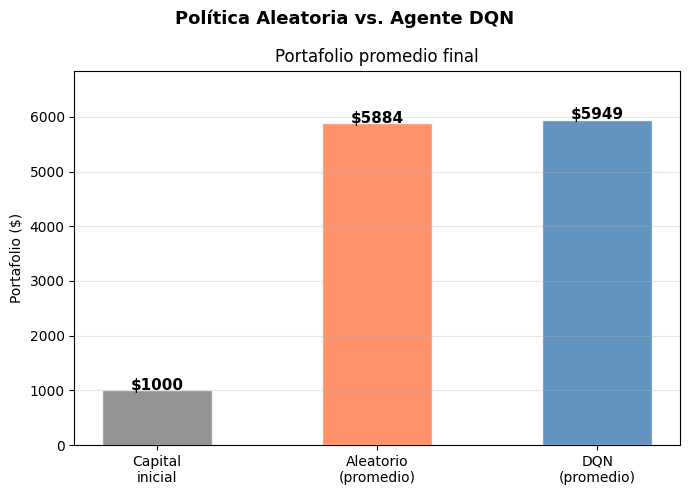

In [55]:
#GRÁFICA
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Política Aleatoria vs. Agente DQN', fontsize=13, fontweight='bold')

# Comparación
labels = ['Capital\ninicial', 'Aleatorio\n(promedio)', 'DQN\n(promedio)']
values = [budget, avg, avg_dqn]
colors = ['gray', 'coral', 'steelblue']
bars = ax.bar(labels, values, color=colors, alpha=0.85, width=0.5, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${val:.0f}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Portafolio promedio final')
ax.set_ylabel('Portafolio ($)')
ax.set_ylim(0, max(values) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Reflexión
Con un presupuesto inicial de $1,000, la política aleatoria obtuvo un portafolio promedio de $5,884 y el agente DQN $5,949. La diferencia es mínima ($65).
Esto probablemente se debe a que el agente DQN necesita más episodios de entrenamiento para aprender patrones útiles del mercado. Con unas veinte corridas y pocos ajustes en los hiperparámetros, su ventaja aún no es significativa. Sin embargo, lo más interesante es que el agente observa un estado, toma una acción, recibe una recompensa y mejora su política con el tiempo, que es exactamente como lo haría un trader real aprendiendo del mercado.